In [2]:
# Imports gerais do notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

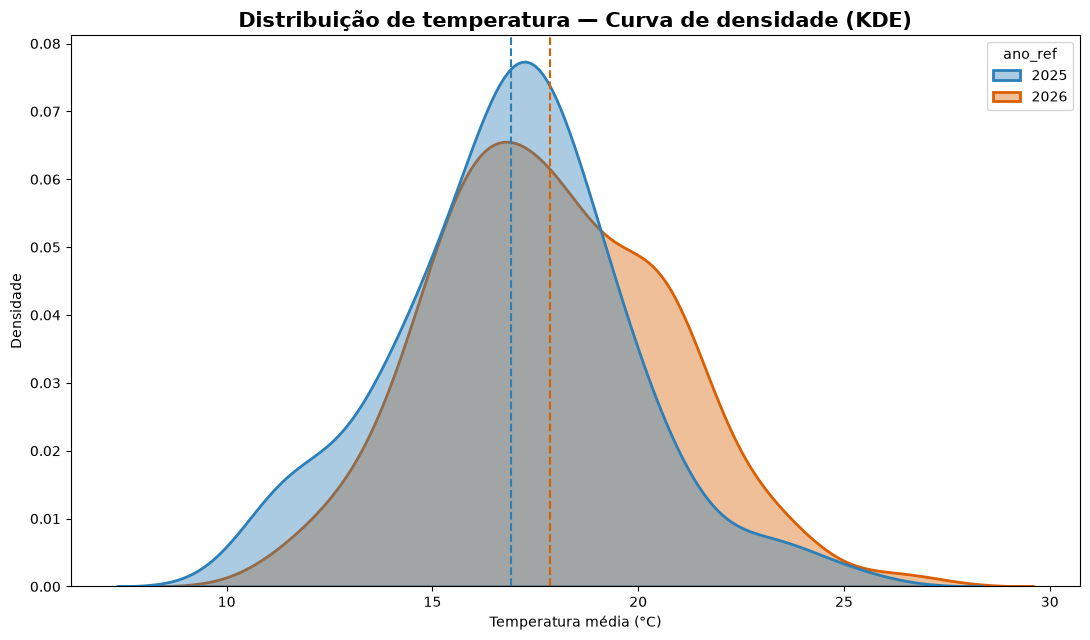

In [3]:
# P2-B: Curva de densidade (KDE)
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
a["ano_ref"], b["ano_ref"] = "2025", "2026"
df = pd.concat([a, b], ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.kdeplot(data=df, x="Temperatura_media", hue="ano_ref", fill=True,
            palette={"2025": COR_2025, "2026": COR_2026}, alpha=0.4, linewidth=2, ax=ax)
for ano, cor in [("2025", COR_2025), ("2026", COR_2026)]:
    media = df[df["ano_ref"] == ano]["Temperatura_media"].mean()
    ax.axvline(media, color=cor, linestyle="--", linewidth=1.5)
ax.set_title("Distribuição de temperatura — Curva de densidade (KDE)", fontsize=15, fontweight="bold")
ax.set_xlabel("Temperatura média (°C)"); ax.set_ylabel("Densidade")
plt.tight_layout()
plt.savefig("p2_b_kde.png", dpi=150)

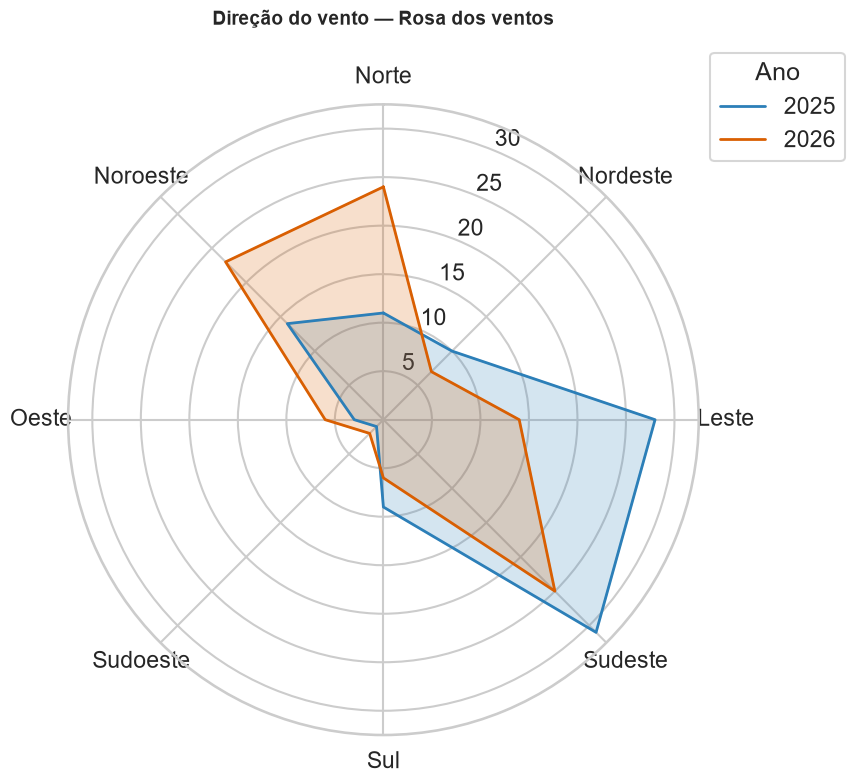

In [13]:
# P6-A: Rosa dos ventos
import pandas as pd, numpy as np, matplotlib.pyplot as plt
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
direcoes = ["Norte","Nordeste","Leste","Sudeste","Sul","Sudoeste","Oeste","Noroeste"]
angulos = {d: i*(360/8) for i, d in enumerate(direcoes)}
cont_a = a["Direcao_vento"].value_counts().reindex(direcoes, fill_value=0)
cont_b = b["Direcao_vento"].value_counts().reindex(direcoes, fill_value=0)
theta = np.deg2rad([angulos[d] for d in direcoes]); theta = np.append(theta, theta[0])
va = np.append(cont_a.values, cont_a.values[0]); vb = np.append(cont_b.values, cont_b.values[0])

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.plot(theta, va, color=COR_2025, linewidth=2, label="2025"); ax.fill(theta, va, color=COR_2025, alpha=0.2)
ax.plot(theta, vb, color=COR_2026, linewidth=2, label="2026"); ax.fill(theta, vb, color=COR_2026, alpha=0.2)
ax.set_xticks(np.deg2rad(list(angulos.values()))); ax.set_xticklabels(direcoes)
ax.set_title("Direção do vento — Rosa dos ventos", fontsize=14, fontweight="bold", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), title="Ano")
plt.tight_layout()
plt.savefig("p6_a_rosa_ventos.png", dpi=150)

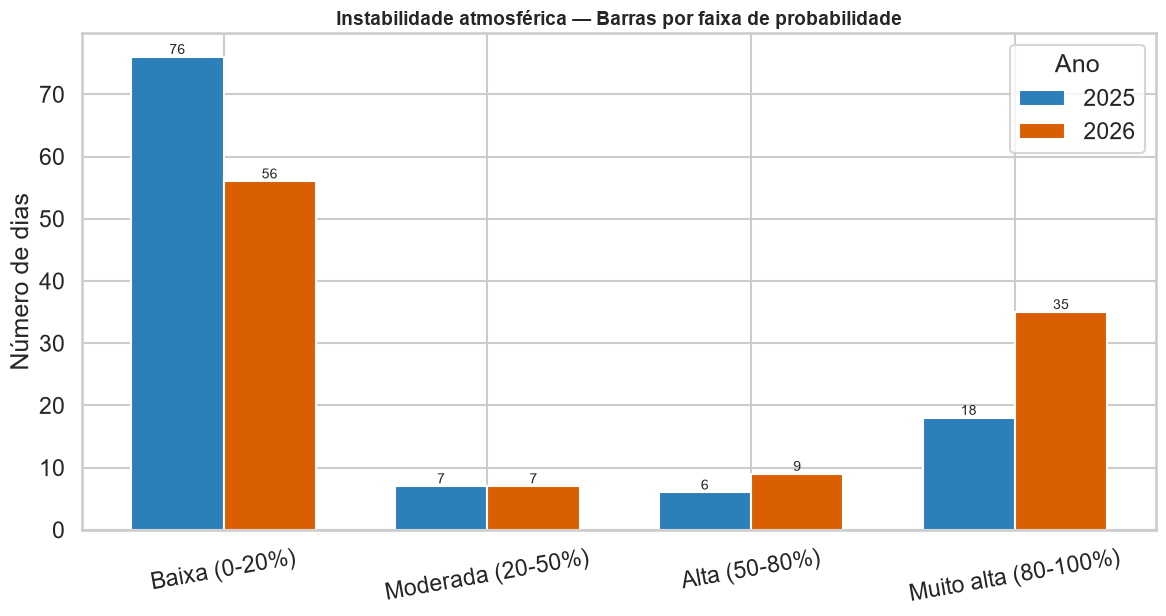

In [8]:
# P4-C: Barras por faixa de probabilidade
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])

bins = [-1, 20, 50, 80, 101]
labels = ["Baixa (0-20%)", "Moderada (20-50%)", "Alta (50-80%)", "Muito alta (80-100%)"]
a["faixa"] = pd.cut(a["Probabilidade_chuva_max"], bins=bins, labels=labels)
b["faixa"] = pd.cut(b["Probabilidade_chuva_max"], bins=bins, labels=labels)
cont_a = a["faixa"].value_counts().reindex(labels)
cont_b = b["faixa"].value_counts().reindex(labels)

x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(12, 6.5))
ba = ax.bar(x - width/2, cont_a.values, width, label="2025", color=COR_2025)
bb = ax.bar(x + width/2, cont_b.values, width, label="2026", color=COR_2026)
ax.bar_label(ba, fontsize=10); ax.bar_label(bb, fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=10)
ax.set_title("Instabilidade atmosférica — Barras por faixa de probabilidade", fontsize=14, fontweight="bold")
ax.set_ylabel("Número de dias"); ax.legend(title="Ano")
plt.tight_layout()
plt.savefig("p4_c_barras_faixas.png", dpi=150)

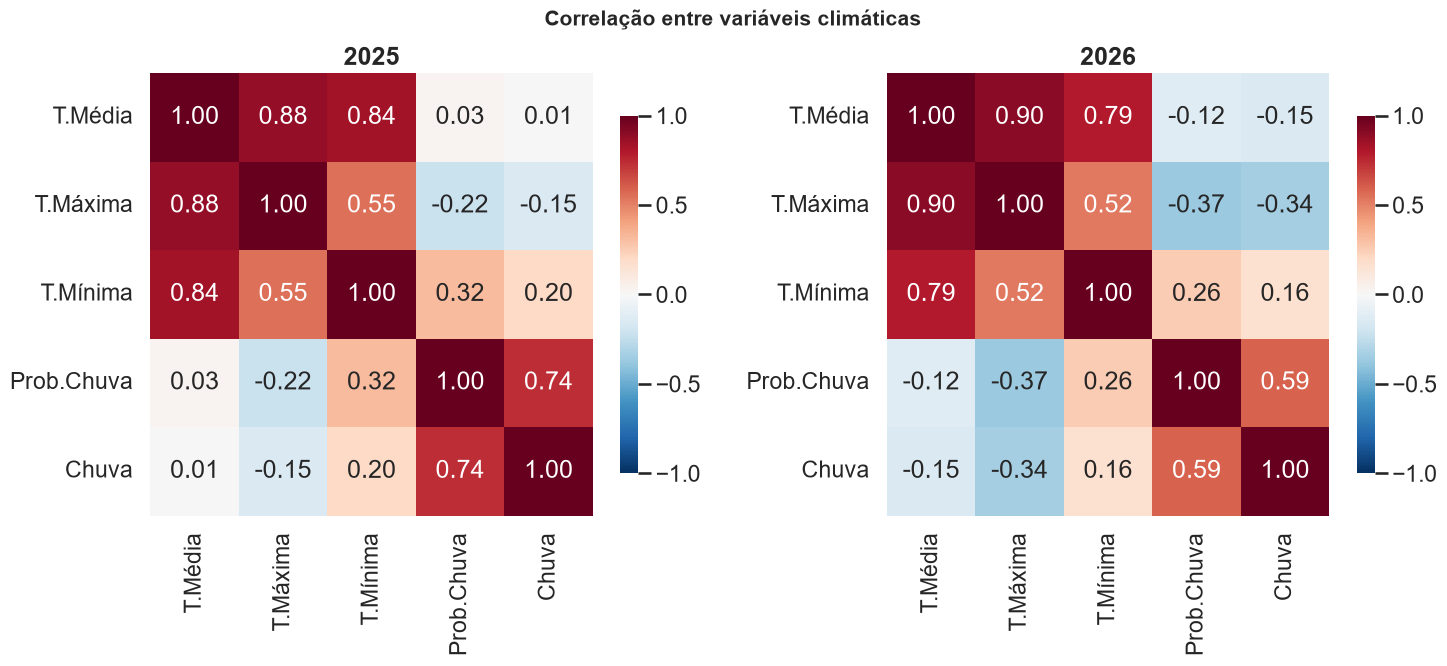

In [17]:
# P8-C: Matriz de correlação
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="white", context="talk")
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
variaveis = ["Temperatura_media","Temperatura_maxima","Temperatura_minima","Probabilidade_chuva_max","Chuva_total"]
nomes_curtos = ["T.Média","T.Máxima","T.Mínima","Prob.Chuva","Chuva"]
corr_a = a[variaveis].corr(); corr_a.columns = nomes_curtos; corr_a.index = nomes_curtos
corr_b = b[variaveis].corr(); corr_b.columns = nomes_curtos; corr_b.index = nomes_curtos

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
sns.heatmap(corr_a, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[0], square=True, cbar_kws={"shrink": 0.8})
axes[0].set_title("2025", fontweight="bold")
sns.heatmap(corr_b, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[1], square=True, cbar_kws={"shrink": 0.8})
axes[1].set_title("2026", fontweight="bold")
fig.suptitle("Correlação entre variáveis climáticas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("p8_c_matriz_correlacao.png", dpi=150)

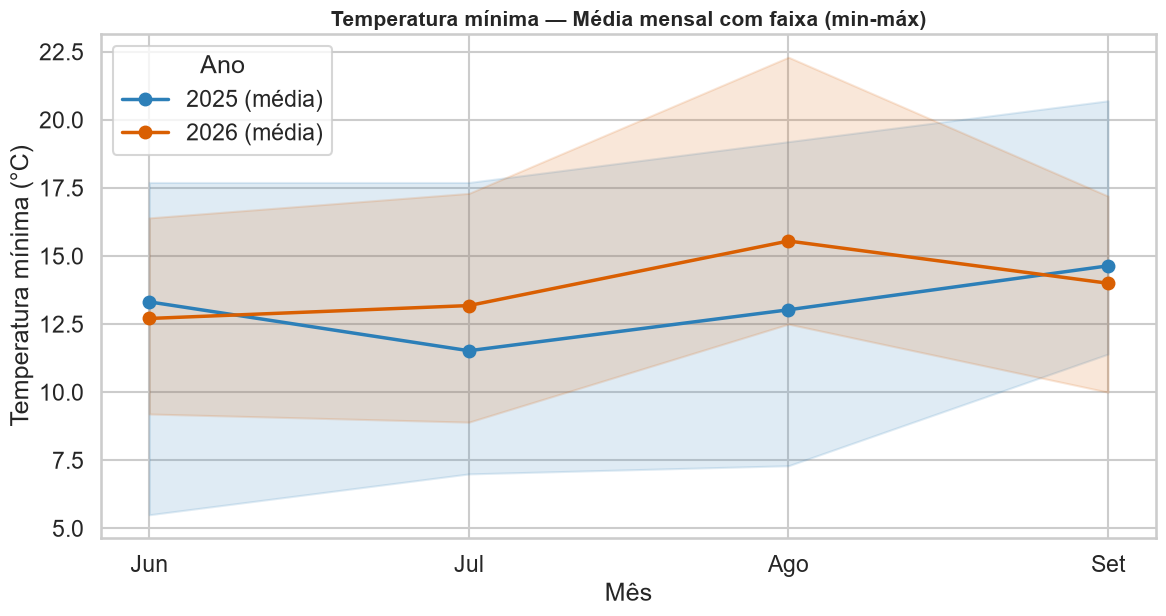

In [18]:
# P9-B: Média mensal com faixa (min-máx)
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
meses_nome = {6:"Jun",7:"Jul",8:"Ago",9:"Set"}; mes_ordem=["Jun","Jul","Ago","Set"]
a["mes_nome"] = a["mes"].map(meses_nome); b["mes_nome"] = b["mes"].map(meses_nome)
resumo_a = a.groupby("mes_nome")["Temperatura_minima"].agg(["mean","min","max"]).reindex(mes_ordem)
resumo_b = b.groupby("mes_nome")["Temperatura_minima"].agg(["mean","min","max"]).reindex(mes_ordem)

fig, ax = plt.subplots(figsize=(12, 6.5))
x = range(len(mes_ordem))
ax.plot(x, resumo_a["mean"], color=COR_2025, marker="o", markersize=9, linewidth=2.5, label="2025 (média)")
ax.fill_between(x, resumo_a["min"], resumo_a["max"], color=COR_2025, alpha=0.15)
ax.plot(x, resumo_b["mean"], color=COR_2026, marker="o", markersize=9, linewidth=2.5, label="2026 (média)")
ax.fill_between(x, resumo_b["min"], resumo_b["max"], color=COR_2026, alpha=0.15)
ax.set_xticks(x); ax.set_xticklabels(mes_ordem)
ax.set_title("Temperatura mínima — Média mensal com faixa (min-máx)", fontsize=15, fontweight="bold")
ax.set_xlabel("Mês"); ax.set_ylabel("Temperatura mínima (°C)")
ax.legend(title="Ano")
plt.tight_layout()
plt.savefig("p9_b_linha_faixa.png", dpi=150)

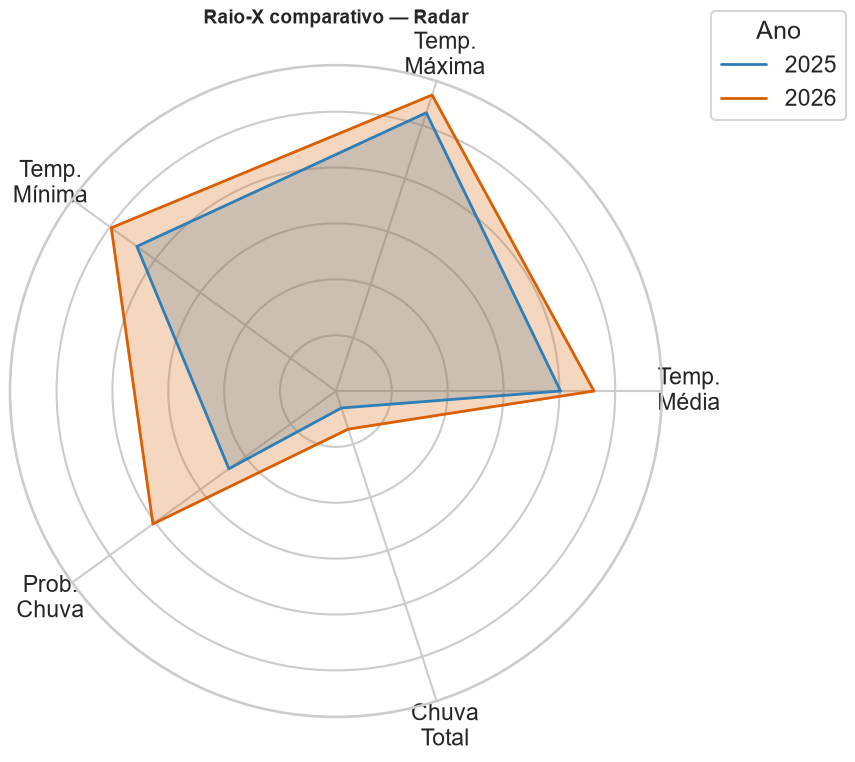

In [19]:
# P10-A: Radar
import pandas as pd, numpy as np, matplotlib.pyplot as plt
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
variaveis = ["Temperatura_media","Temperatura_maxima","Temperatura_minima","Probabilidade_chuva_max","Chuva_total"]
labels_radar = ["Temp.\nMédia","Temp.\nMáxima","Temp.\nMínima","Prob.\nChuva","Chuva\nTotal"]
medias_a = a[variaveis].mean(); medias_b = b[variaveis].mean()
norm_min = pd.concat([a[variaveis], b[variaveis]]).min()
norm_max = pd.concat([a[variaveis], b[variaveis]]).max()
norm_a = ((medias_a - norm_min) / (norm_max - norm_min)).values
norm_b = ((medias_b - norm_min) / (norm_max - norm_min)).values
angles = np.linspace(0, 2*np.pi, len(variaveis), endpoint=False).tolist()
norm_a = np.concatenate((norm_a, [norm_a[0]])); norm_b = np.concatenate((norm_b, [norm_b[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
ax.plot(angles, norm_a, color=COR_2025, linewidth=2, label="2025"); ax.fill(angles, norm_a, color=COR_2025, alpha=0.25)
ax.plot(angles, norm_b, color=COR_2026, linewidth=2, label="2026"); ax.fill(angles, norm_b, color=COR_2026, alpha=0.25)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_radar); ax.set_yticklabels([])
ax.set_title("Raio-X comparativo — Radar", fontsize=14, fontweight="bold", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), title="Ano")
plt.tight_layout()
plt.savefig("p10_a_radar.png", dpi=150)